Libraries loaded successfully.
TensorFlow version: 2.20.0

Data shape: (219800, 3)
Columns: ['simulation', 'day', 'bs_price']
Simulations: 200
Day range: -90 to 1008
Price range: 0.0000 to 22739.18

First few rows:
   simulation  day     bs_price
0           0  -90  1152.323606
1           0  -89  1089.565969
2           0  -88  1024.738395
3           0  -87  1022.199501
4           0  -86   966.657777

Dataset after windowing:
  X shape: (217800, 10)  (samples x window_size)
  y shape: (217800,)  (samples,)
  Each sample: 10 past prices → 1 future price

After scaling:
  X range: [0.000, 1.000]
  y range: [0.000, 1.000]

Data split:
  Training:   152,547 samples
  Validation: 32,583 samples
  Test:       32,670 samples


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)


Training MLP model...
Epoch 1/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.0012 - mae: 0.0193 - val_loss: 8.4315e-04 - val_mae: 0.0182
Epoch 2/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3.6773e-04 - mae: 0.0125 - val_loss: 4.3237e-04 - val_mae: 0.0147
Epoch 3/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 3.1051e-04 - mae: 0.0117 - val_loss: 3.9132e-04 - val_mae: 0.0149
Epoch 4/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.8089e-04 - mae: 0.0112 - val_loss: 4.5482e-04 - val_mae: 0.0159
Epoch 5/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.7138e-04 - mae: 0.0111 - val_loss: 5.2040e-04 - val_mae: 0.0180
Epoch 6/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.6231e-04 - mae: 0.0109 - val_loss: 6.4551e-04 - val_mae: 0.0176
Epoch 7/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.5846e-04 - mae: 0.0108 - val_loss: 5.0295e-04 - val_mae: 0.0160
Epoch 8/100
596/596 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 2.5104e-04 - mae: 0.0107 - val_

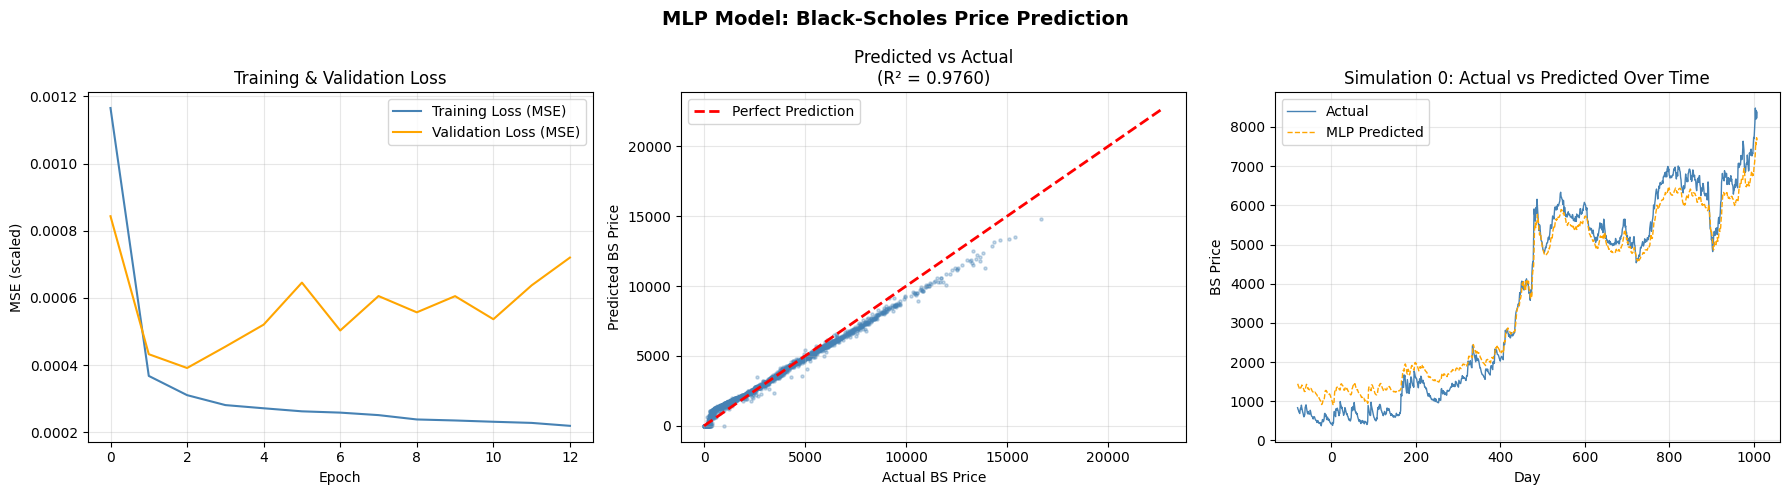


Plot saved as 'mlp_results.png'

EXAMPLE: Predicting Tomorrow's Price
  Last 10 days (simulation 0): [7518.78 7732.56 7704.08 7929.77 8119.06 8483.95 8196.21 8422.43 8223.97
 8377.34]
  Predicted tomorrow's price: 7713.1618
  Actual last known price:    8377.3445

Done! Model trained and evaluated successfully.


In [2]:
"""
MLP Model for Black-Scholes Price Prediction
LSE Statistical Challenge 2026 - Aviva

Goal: Predict tomorrow's BS price using a window of previous days' prices.
Data: Each simulation has ~1099 days (day -90 to 1008), with bs_price as the target.
"""

# ============================================================
# STEP 1: Import Libraries
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("Libraries loaded successfully.")
print(f"TensorFlow version: {tf.__version__}")


# ============================================================
# STEP 2: Load and Explore the Data
# ============================================================
# Load the sample data (200 simulations)
# For the full dataset (10,000 simulations), simply change the file path below
df = pd.read_csv('data_mlp.csv')  # <-- Change this path to the full dataset when ready

print(f"\nData shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Simulations: {df['simulation'].nunique()}")
print(f"Day range: {df['day'].min()} to {df['day'].max()}")
print(f"Price range: {df['bs_price'].min():.4f} to {df['bs_price'].max():.2f}")
print(f"\nFirst few rows:\n{df.head()}")


# ============================================================
# STEP 3: Create Input Windows (Sliding Window Approach)
# ============================================================
# The MLP does not naturally handle sequences like LSTM does.
# To give it "memory" of past prices, we use a SLIDING WINDOW:
#   - Input (X): the prices of the last N days
#   - Output (y): the price of the NEXT day (tomorrow)
#
# Example with WINDOW_SIZE=5:
#   X = [price_day1, price_day2, price_day3, price_day4, price_day5]
#   y = price_day6  (what we want to predict)

WINDOW_SIZE = 10  # Number of past days used to predict the next day
                  # Try: 5, 10, 20, 30 — larger windows capture longer trends

def create_windows(prices, window_size):
    """
    Converts a 1D array of prices into (X, y) pairs using a sliding window.
    
    Example (window_size=3):
    prices = [100, 110, 105, 120, 115]
    X[0] = [100, 110, 105], y[0] = 120
    X[1] = [110, 105, 120], y[1] = 115
    """
    X, y = [], []
    for i in range(len(prices) - window_size):
        X.append(prices[i : i + window_size])   # past WINDOW_SIZE prices
        y.append(prices[i + window_size])        # next day's price
    return np.array(X), np.array(y)

# Build windows from ALL simulations
all_X = []
all_y = []

# Sort data so days are in order within each simulation
df = df.sort_values(['simulation', 'day']).reset_index(drop=True)

for sim_id, group in df.groupby('simulation'):
    prices = group['bs_price'].values   # all prices for this simulation in order
    X_sim, y_sim = create_windows(prices, WINDOW_SIZE)
    all_X.append(X_sim)
    all_y.append(y_sim)

# Stack all simulations together into one big dataset
X = np.vstack(all_X)
y = np.concatenate(all_y)

print(f"\nDataset after windowing:")
print(f"  X shape: {X.shape}  (samples x window_size)")
print(f"  y shape: {y.shape}  (samples,)")
print(f"  Each sample: {WINDOW_SIZE} past prices → 1 future price")


# ============================================================
# STEP 4: Scale the Data (IMPORTANT for Neural Networks)
# ============================================================
# Neural networks train much better when inputs are on a similar scale.
# We use MinMaxScaler to compress all values into [0, 1].
#
# WHY THIS HELPS WITH "NO NEGATIVE PRICES":
#   MinMaxScaler maps min_price -> 0 and max_price -> 1.
#   Since bs_price >= 0 always, the scaled values will also be >= 0.
#   We then use a ReLU output activation (see model below) which also
#   outputs >= 0, ensuring our predictions are never negative.

scaler = MinMaxScaler(feature_range=(0, 1))

# Fit scaler on ALL prices (X and y together) so the scale is consistent
all_prices = np.concatenate([X.flatten(), y])
scaler.fit(all_prices.reshape(-1, 1))

# Apply scaling
X_scaled = scaler.transform(X.reshape(-1, 1)).reshape(X.shape)
y_scaled = scaler.transform(y.reshape(-1, 1)).flatten()

print(f"\nAfter scaling:")
print(f"  X range: [{X_scaled.min():.3f}, {X_scaled.max():.3f}]")
print(f"  y range: [{y_scaled.min():.3f}, {y_scaled.max():.3f}]")


# ============================================================
# STEP 5: Train / Validation / Test Split
# ============================================================
# We split ONCE into train (70%), validation (15%), test (15%)
# NOTE: We do NOT shuffle here because we want the split to be
#       representative of different simulations, not random time points.
#       (Shuffling would be fine too since windows are already created.)

X_temp, X_test, y_temp, y_test = train_test_split(
    X_scaled, y_scaled, test_size=0.15, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=42  # 0.176 of 85% ≈ 15% of total
)

print(f"\nData split:")
print(f"  Training:   {X_train.shape[0]:,} samples")
print(f"  Validation: {X_val.shape[0]:,} samples")
print(f"  Test:       {X_test.shape[0]:,} samples")


# ============================================================
# STEP 6: Build the MLP Model
# ============================================================
# Architecture: Input(10) -> Dense(128) -> Dropout -> Dense(64) -> Dropout -> Dense(32) -> Output(1)
#
# LAYER EXPLANATIONS:
#   Dense(n): Fully connected layer with n neurons. Each neuron computes:
#             output = activation(weight * input + bias)
#   Dropout(rate): During training only, randomly "switches off" a fraction of
#                  neurons to prevent overfitting (memorising training data).
#   Activation 'relu': ReLU = max(0, x). Outputs 0 for negative inputs,
#                       otherwise passes the value through. Fast and effective.
#   Output activation 'relu': Ensures the final price prediction is >= 0,
#                              which matches the fact that option prices can't be negative.

model = Sequential([
    # --- Hidden Layer 1: 128 neurons ---
    # Takes the 10 input prices and finds complex patterns
    Dense(128, activation='relu', input_shape=(WINDOW_SIZE,)),
    Dropout(0.2),   # Drop 20% of neurons randomly during training

    # --- Hidden Layer 2: 64 neurons ---
    # Compresses the learned patterns into a smaller representation
    Dense(64, activation='relu'),
    Dropout(0.2),

    # --- Hidden Layer 3: 32 neurons ---
    # Further refinement before making the final prediction
    Dense(32, activation='relu'),
    Dropout(0.1),   # Less dropout near the output

    # --- Output Layer: 1 neuron ---
    # Outputs the predicted (scaled) price for tomorrow
    # ReLU here guarantees non-negative output
    Dense(1, activation='relu')
])

# Compile: tell the model HOW to learn
model.compile(
    optimizer='adam',       # Adam: an adaptive learning rate optimizer, very standard choice
    loss='mse',             # Mean Squared Error: penalises large errors more than small ones
    metrics=['mae']         # Also track Mean Absolute Error for interpretability
)

model.summary()


# ============================================================
# STEP 7: Train the Model
# ============================================================
# EPOCHS: One epoch = the model has seen ALL training samples once.
#   With 50 epochs, the model makes 50 full passes through the training data.
#   Each pass updates the weights to reduce the prediction error.
#   We use EarlyStopping: if the validation loss doesn't improve for 10 epochs,
#   training stops automatically. This prevents overfitting and saves time.
#   The model restores the weights from the best epoch (lowest val_loss).

early_stop = EarlyStopping(
    monitor='val_loss',     # Watch the validation loss (not training loss)
    patience=10,            # Stop if no improvement for 10 consecutive epochs
    restore_best_weights=True  # Roll back to the best model found
)

print("\nTraining MLP model...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,             # Maximum epochs (early stopping will likely trigger before this)
    batch_size=256,         # Process 256 samples at a time before updating weights
                            # Larger batch = faster training, less noisy updates
    callbacks=[early_stop],
    verbose=1
)

print(f"\nTraining stopped at epoch {len(history.history['loss'])}")


# ============================================================
# STEP 8: Evaluate the Model on the Test Set
# ============================================================
# The test set was never seen during training — it gives an unbiased performance estimate.

y_pred_scaled = model.predict(X_test, verbose=0).flatten()

# Convert predictions and actuals back to original price scale
y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

# Ensure no negative predictions (safety net, ReLU should handle this)
y_pred = np.maximum(y_pred, 0)

# Calculate metrics
mse  = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)
mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-8))) * 100  # avoid div by zero

print("\n" + "="*50)
print("TEST SET PERFORMANCE METRICS")
print("="*50)
print(f"  MSE  (Mean Squared Error):           {mse:>12.4f}")
print(f"  RMSE (Root Mean Squared Error):      {rmse:>12.4f}")
print(f"  MAE  (Mean Absolute Error):          {mae:>12.4f}")
print(f"  R²   (Coefficient of Determination): {r2:>12.4f}  (1.0 = perfect)")
print(f"  MAPE (Mean Absolute % Error):        {mape:>11.2f}%")


# ============================================================
# STEP 9: Visualisations
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('MLP Model: Black-Scholes Price Prediction', fontsize=14, fontweight='bold')

# --- Plot 1: Training History ---
ax = axes[0]
ax.plot(history.history['loss'], label='Training Loss (MSE)', color='steelblue')
ax.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange')
ax.set_title('Training & Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE (scaled)')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 2: Predicted vs Actual (scatter, sample) ---
ax = axes[1]
sample_idx = np.random.choice(len(y_true), size=min(2000, len(y_true)), replace=False)
ax.scatter(y_true[sample_idx], y_pred[sample_idx], alpha=0.3, s=5, color='steelblue')
min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')
ax.set_title(f'Predicted vs Actual\n(R² = {r2:.4f})')
ax.set_xlabel('Actual BS Price')
ax.set_ylabel('Predicted BS Price')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Plot 3: One simulation's prediction over time ---
ax = axes[2]
# Pick simulation 0 from full dataset to show time series prediction
sim0 = df[df['simulation'] == 0].sort_values('day')
prices_sim0 = sim0['bs_price'].values
X_sim0, y_sim0 = create_windows(prices_sim0, WINDOW_SIZE)
X_sim0_scaled = scaler.transform(X_sim0.reshape(-1, 1)).reshape(X_sim0.shape)
y_sim0_pred_scaled = model.predict(X_sim0_scaled, verbose=0).flatten()
y_sim0_pred = scaler.inverse_transform(y_sim0_pred_scaled.reshape(-1, 1)).flatten()
y_sim0_pred = np.maximum(y_sim0_pred, 0)
days_sim0 = sim0['day'].values[WINDOW_SIZE:]  # days corresponding to predictions

ax.plot(days_sim0, prices_sim0[WINDOW_SIZE:],
        label='Actual', color='steelblue', linewidth=1)
ax.plot(days_sim0, y_sim0_pred, label='MLP Predicted', color='orange',
        linewidth=1, linestyle='--')
ax.set_title('Simulation 0: Actual vs Predicted Over Time')
ax.set_xlabel('Day')
ax.set_ylabel('BS Price')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('mlp_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as 'mlp_results.png'")


# ============================================================
# STEP 10: Predict Tomorrow's Price (Example Usage)
# ============================================================
# To predict the next day's price given the last WINDOW_SIZE days:

def predict_tomorrow(last_n_prices, model, scaler, window_size=WINDOW_SIZE):
    """
    Predict tomorrow's price given the last `window_size` prices.
    
    Parameters:
        last_n_prices: list or array of the last `window_size` prices (in order)
        model: trained Keras model
        scaler: fitted MinMaxScaler
        window_size: number of days used as input (must match model)
    
    Returns:
        Predicted price for tomorrow (float, always >= 0)
    """
    assert len(last_n_prices) == window_size, f"Provide exactly {window_size} prices"
    prices_array = np.array(last_n_prices).reshape(-1, 1)
    prices_scaled = scaler.transform(prices_array).flatten()
    X_input = prices_scaled.reshape(1, window_size)  # shape (1, window_size)
    pred_scaled = model.predict(X_input, verbose=0)[0][0]
    pred_price = scaler.inverse_transform([[pred_scaled]])[0][0]
    return max(pred_price, 0)  # ensure non-negative

# --- Example: use the last 10 days of simulation 0 ---
last_10_prices = prices_sim0[-WINDOW_SIZE:]
tomorrow_prediction = predict_tomorrow(last_10_prices, model, scaler)

print("\n" + "="*50)
print("EXAMPLE: Predicting Tomorrow's Price")
print("="*50)
print(f"  Last {WINDOW_SIZE} days (simulation 0): {last_10_prices.round(2)}")
print(f"  Predicted tomorrow's price: {tomorrow_prediction:.4f}")
print(f"  Actual last known price:    {prices_sim0[-1]:.4f}")

print("\nDone! Model trained and evaluated successfully.")

In [3]:
wmape = (np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)) * 100
print(f"  WMAPE (Weighted Mean Absolute % Error):  {wmape:>10.2f}%")

  WMAPE (Weighted Mean Absolute % Error):       10.21%
